# 特征降维

## 降维概述

维数灾难(Curse of Dimensionality)：通常是指在涉及到向量的计算的问题中，随着维数的增加，计算量呈指数倍增长的一种现象。在很多机器学习问题中，训练集中的每条数据经常伴随着上千、甚至上万个特征。要处理这所有的特征的话，不仅会让训练非常缓慢，还会极大增加搜寻良好解决方案的困难。这个问题就是我们常说的维数灾难。

维数灾难涉及数字分析、抽样、组合、机器学习、数据挖掘和数据库等诸多领域。在机器学习的建模过程中，通常指的是随着特征数量的增多，计算量会变得很大，如特征达到上亿维的话，在进行计算的时候是算不出来的。有的时候，维度太大也会导致机器学习性能的下降，并不是特征维度越大越好，模型的性能会随着特征的增加先上升后下降。

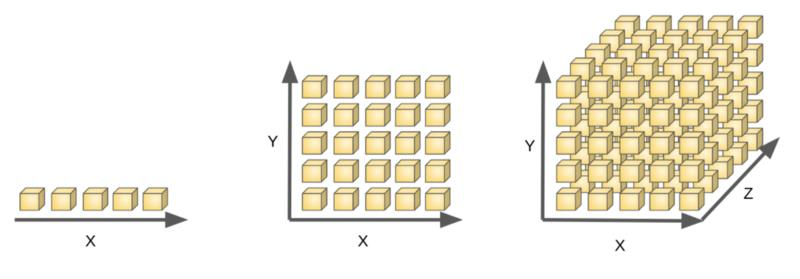

## 什么是降维？

降维(Dimensionality Reduction)是将训练数据中的样本(实例)从高维空间转换到低维空间，该过程与信息论中有损压缩概念密切相关。同时要明白的，**不存在完全无损的降维。**

**降维是指在某些限定条件下，降低随机变量(特征)个数，得到一组“不相关”主变量的过程**

### 为什么要降维？
- 高维数据增加了运算的难度
- 高维使得学习算法的泛化能力变弱（例如，在最近邻分类器中，样本复杂度随着维度成指数增长），维度越高，算法的搜索难度和成本就越大。
- 降维能够增加数据的可读性，利于发掘数据的有意义的结构

### 降维的主要作用

- 减少冗余特征，降低数据维度
- 数据可视化


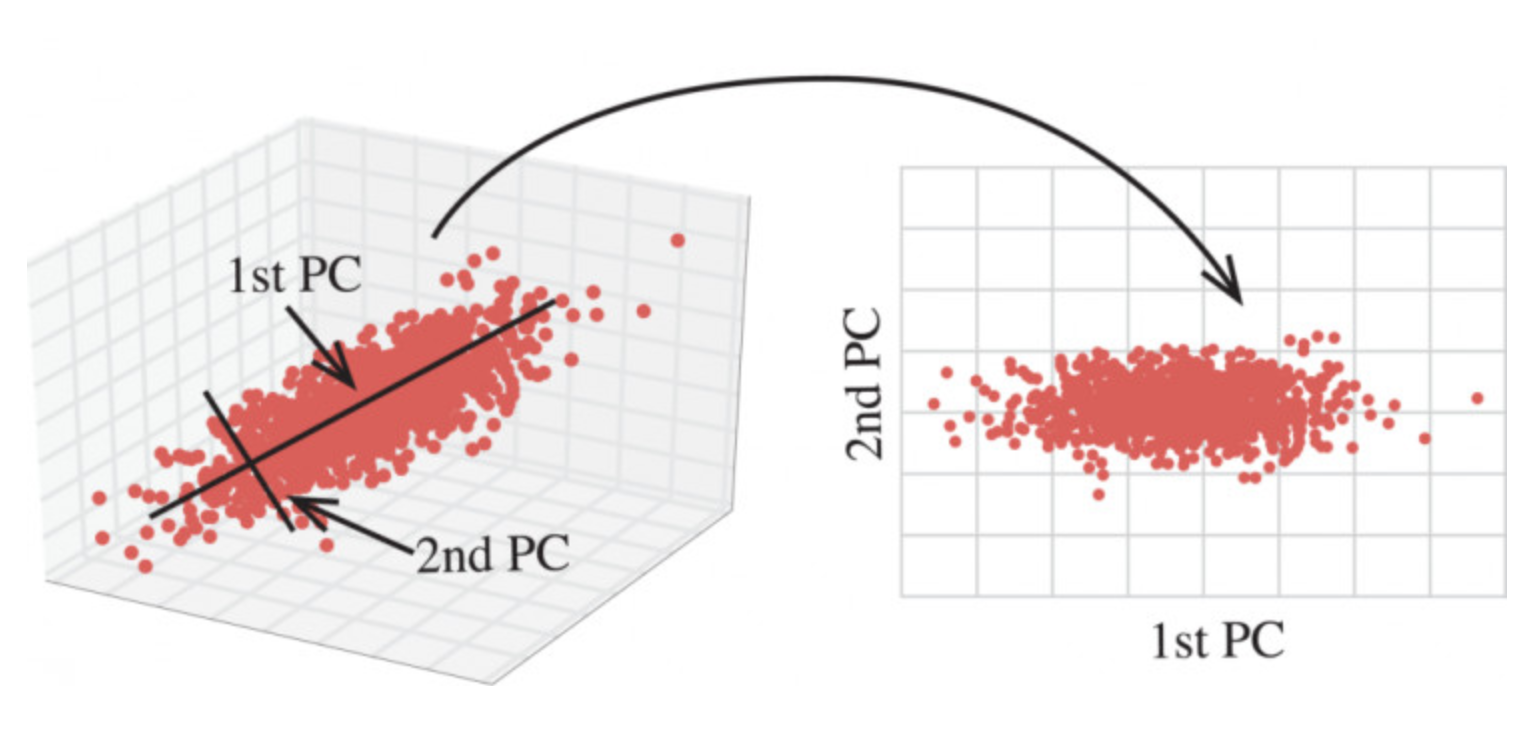

## 降维方法
- 特征选择
- 主成分分析（可以理解一种特征提取的方式）

### 什么是特征选择？
数据中包含冗余或无关变量（或称特征、属性、指标等），旨在从原有特征中找出主要特征。
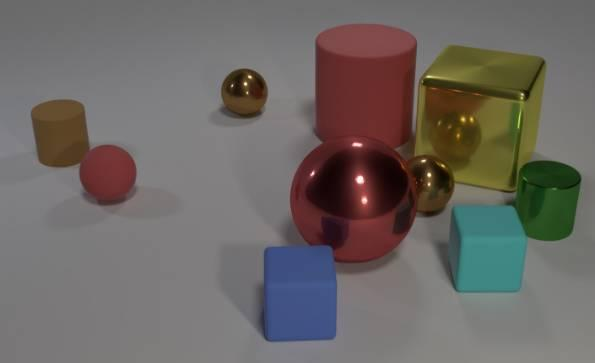

数据的特征非常多，但最终，提取的特征应该要服从我们的目的，还是拿上图举例子，假如我想知道有多少个立方体， 上来就把形状，颜色，大小等feature 全提了个遍是非常不明智的，这就是在浪费计算资源， 所以我们只需要选择形状这个feature就好啦。

#### 方法
- Filter(过滤式)：主要探究特征本身特点、特征与特征和目标值之间关联
    - 方差选择法：低方差特征过滤
    - 相关系数
- Embedded (嵌入式)：算法自动选择特征（特征与目标值之间的关联）
    - 决策树:信息熵、信息增益
    - 正则化：L1、L2
    - 深度学习：卷积等
    
#### 模块
```
sklearn.feature_selection
```

#### 过滤式
**低方差特征过滤**
删除低方差的一些特征，前面讲过方差的意义。再结合方差的大小来考虑这个方式的角度。

- 特征方差小：某个特征大多样本的值比较相近
- 特征方差大：某个特征很多样本的值都有差别

**API**
- sklearn.feature_selection.VarianceThreshold(threshold = 0.0)
    - 删除所有低方差特征
    - Variance.fit_transform(X)
        - X:numpy array格式的数据[n_samples,n_features]
        - 返回值：训练集差异低于threshold的特征将被删除。默认值是保留所有非零方差特征，即删除所有样本中具有相同值的特征。

In [1]:
from sklearn.feature_selection import VarianceThreshold
X = [[0, 2, 0, 3], [0, 1, 4, 3], [0, 1, 1, 3]]
selector = VarianceThreshold(threshold = 0)
selector.fit_transform(X)

array([[2, 0],
       [1, 4],
       [1, 1]])

## 主成分分析

那么更好的理解PCA呢？我们来看一张图
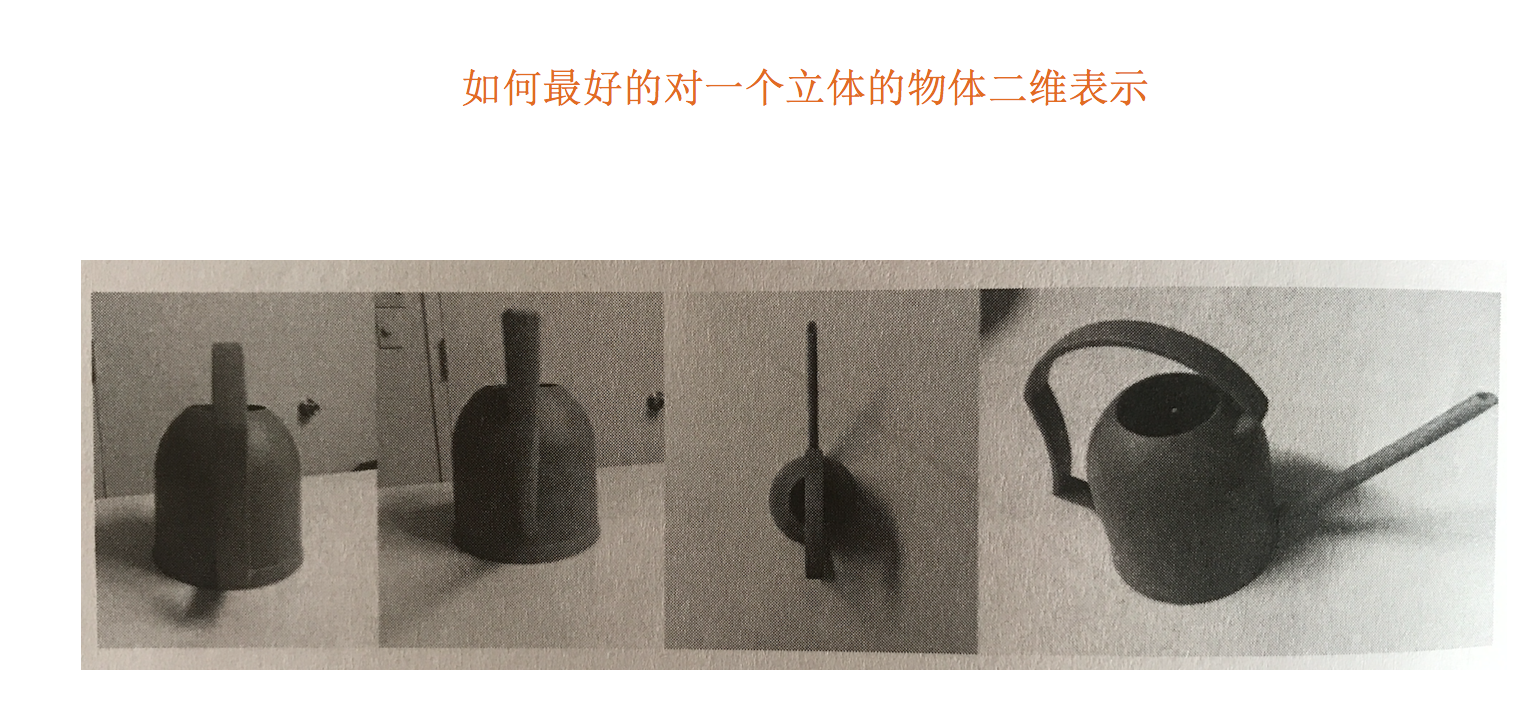

### 什么是主成分分析(PCA)?
主成分分析（Principal Component Analysis,PCA）是一种降维方法，通过将一个大的特征集转换成一个较小的特征集，这个特征集仍然包含了原始数据中的大部分信息，从而降低了原始数据的维数。

减少一个数据集的特征数量自然是以牺牲准确性为代价的，但降维的诀窍是用一点准确性换取简单性。因为更小的数据集更容易探索和可视化，并且对于机器学习算法来说，分析数据会更快、更容易，而不需要处理额外的特征。

- 定义：高维数据转化为低维数据的过程，在此过程中可能会舍弃原有数据、创造新的变量

- 作用：是数据维数压缩，尽可能降低原数据的维数（复杂度），损失少量信息。

- 应用：回归分析或者聚类分析当中

```
对于信息一词，在决策树中会进行介绍
```

### 计算案例理解
假设对于给定5个点，数据如下
```
(-1,-2)
(-1, 0)
( 0, 0)
( 2, 1)
( 0, 1)
```
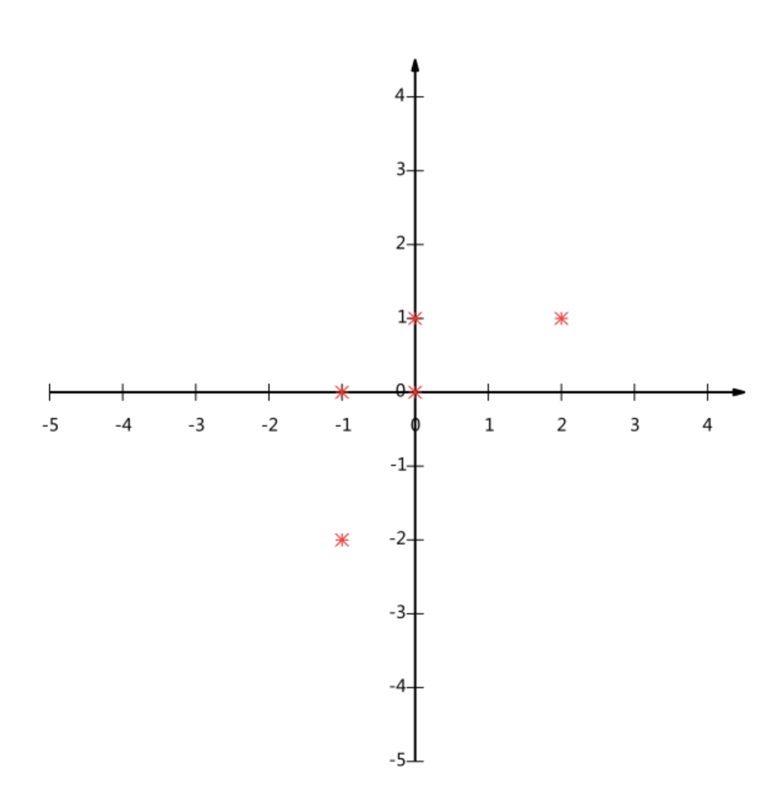

要求：将这个二维的数据简化成一维？ 并且损失少量的信息
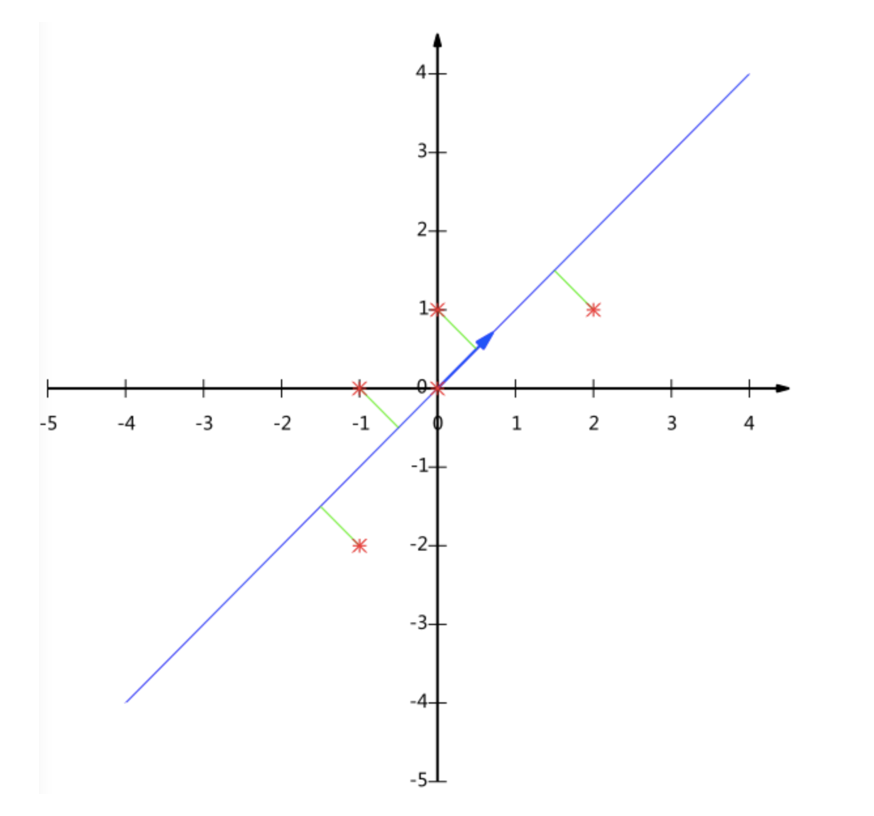

这个过程如何计算的呢？找到一个合适的直线，通过一个矩阵运算得出主成分分析的结果
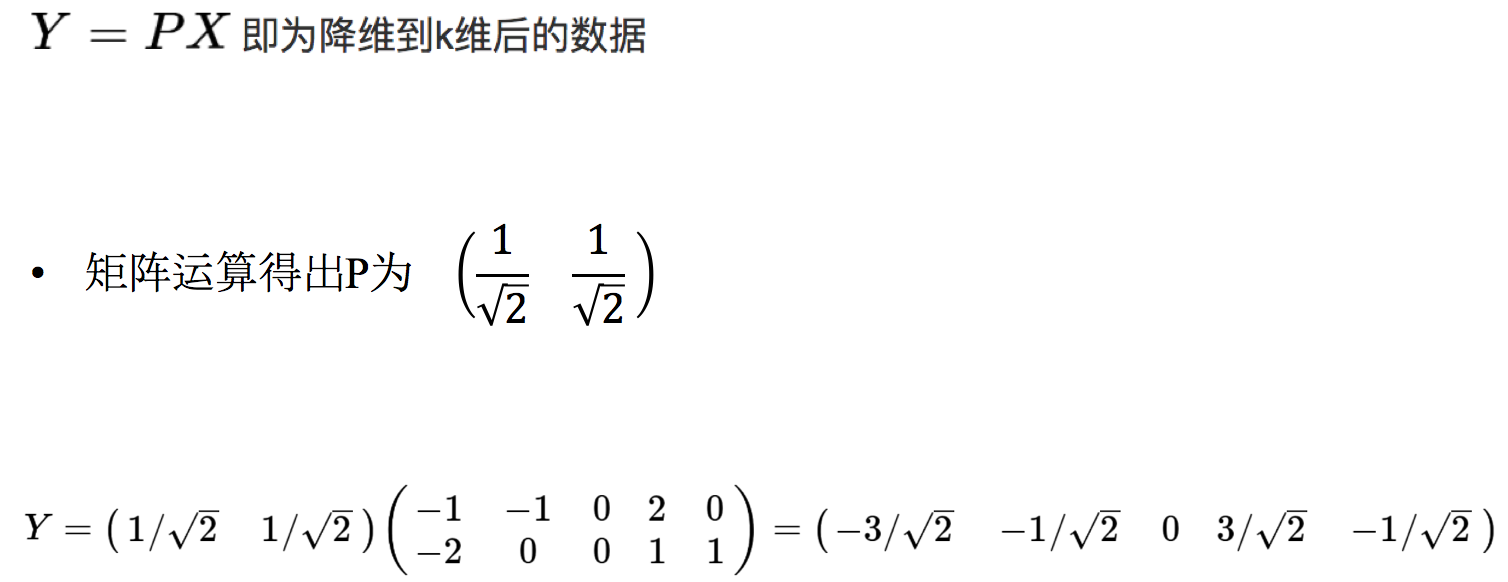

### API
- sklearn.decomposition.PCA(n_components=None)
    - 将数据分解为较低维数空间
    - n_components:
        - 小数：表示保留百分之多少的信息
        - 整数：减少到多少特征
    - PCA.fit_transform(X) X:numpy array格式的数据[n_samples,n_features]
    - 返回值：转换后指定维度的array
    
### 数据计算
拿的数据计算一下
```
(-1,-2)
(-1, 0)
( 0, 0)
( 2, 1)
( 0, 1)
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. 准备数据（5个2维坐标点）
# 格式：每行一个样本，每列一个特征（这里列1=x坐标，列2=y坐标）
data = np.array([
    (-1, -2),
    (-1, 0),
    (0, 0),
    (2, 1),
    (0, 1)
])
print("原始数据（5个样本，2个特征）：")
print(data)
print(f"原始数据形状：{data.shape}\n")

# 2. 初始化PCA模型，指定降维后的维度（n_components=1，降到1维）
pca = PCA(n_components=1)

# 3. 执行降维（自动中心化数据，无需额外标准化，PCA对尺度不敏感）
data_reduced = pca.fit_transform(data)

print("降维后数据（5个样本，1个特征）：")
print(data_reduced)

原始数据（5个样本，2个特征）：
[[-1 -2]
 [-1  0]
 [ 0  0]
 [ 2  1]
 [ 0  1]]
原始数据形状：(5, 2)

降维后数据（5个样本，1个特征）：
[[ 2.12132034]
 [ 0.70710678]
 [-0.        ]
 [-2.12132034]
 [-0.70710678]]
